In [1]:
# Cell 1: Imports and Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Libraries imported")

✓ Libraries imported


In [2]:
# Cell 2: Load Stock Data
data_dir = Path('../data/raw')

# Load SPY data
spy_df = pd.read_csv(data_dir / 'SPY_historical.csv', index_col=0, parse_dates=True)
print(f"SPY data shape: {spy_df.shape}")
print(f"Date range: {spy_df.index[0]} to {spy_df.index[-1]}")
spy_df.head()

SPY data shape: (138, 8)
Date range: 2025-05-01 00:00:00-04:00 to 2025-11-14 00:00:00-05:00


,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains
Date,,,,,,,,
2025-05-01 00:00:00-04:00,557.173549,560.852456,554.677857,555.284363,63186100,0.0,0.0,0.0
2025-05-02 00:00:00-04:00,561.508650,565.137854,559.172079,563.527100,60717300,0.0,0.0,0.0
2025-05-05 00:00:00-04:00,559.361014,563.417758,558.495981,560.295654,38659200,0.0,0.0,0.0
2025-05-06 00:00:00-04:00,554.747455,560.136522,553.783017,555.612488,48264700,0.0,0.0,0.0
2025-05-07 00:00:00-04:00,556.954801,560.603849,552.868199,557.949097,55588000,0.0,0.0,0.0


In [3]:
# Cell 3: Basic Statistics
print("Summary Statistics:")
print(spy_df[['Open', 'High', 'Low', 'Close', 'Volume']].describe())

Summary Statistics:
             Open        High         Low       Close        Volume
count  138.000000  138.000000  138.000000  138.000000  1.380000e+02
mean   631.782999  634.338121  628.869715  631.998104  7.233853e+07
std     35.132448   34.804754   34.834470   34.785553  1.668952e+07
min    554.747455  560.136522  552.868199  555.284363  3.760340e+07
25%    597.917324  601.153747  596.274229  599.806488  6.183228e+07
50%    635.727479  637.043832  632.745750  635.258789  6.960145e+07
75%    662.297516  665.640015  658.808626  662.837479  8.031020e+07
max    688.719971  689.700012  684.830017  687.390015  1.594226e+08


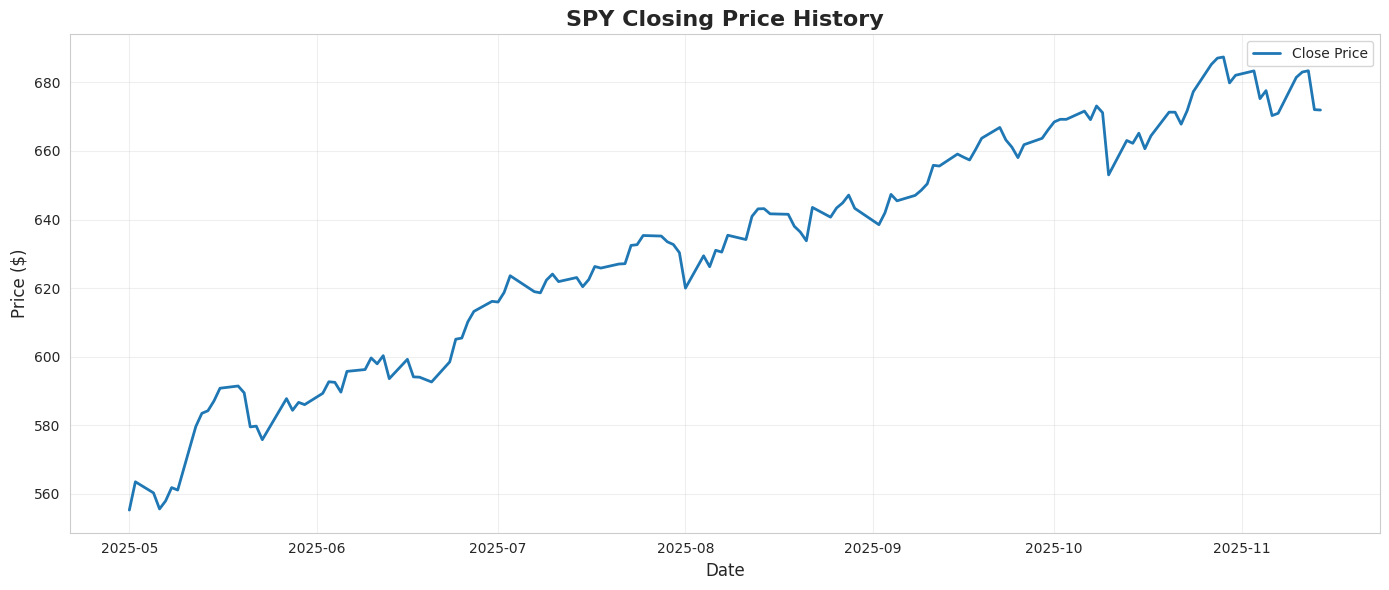

In [4]:
# Cell 4: Plot Price History
plt.figure(figsize=(14, 6))
plt.plot(spy_df.index, spy_df['Close'], label='Close Price', linewidth=2)
plt.title('SPY Closing Price History', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price ($)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

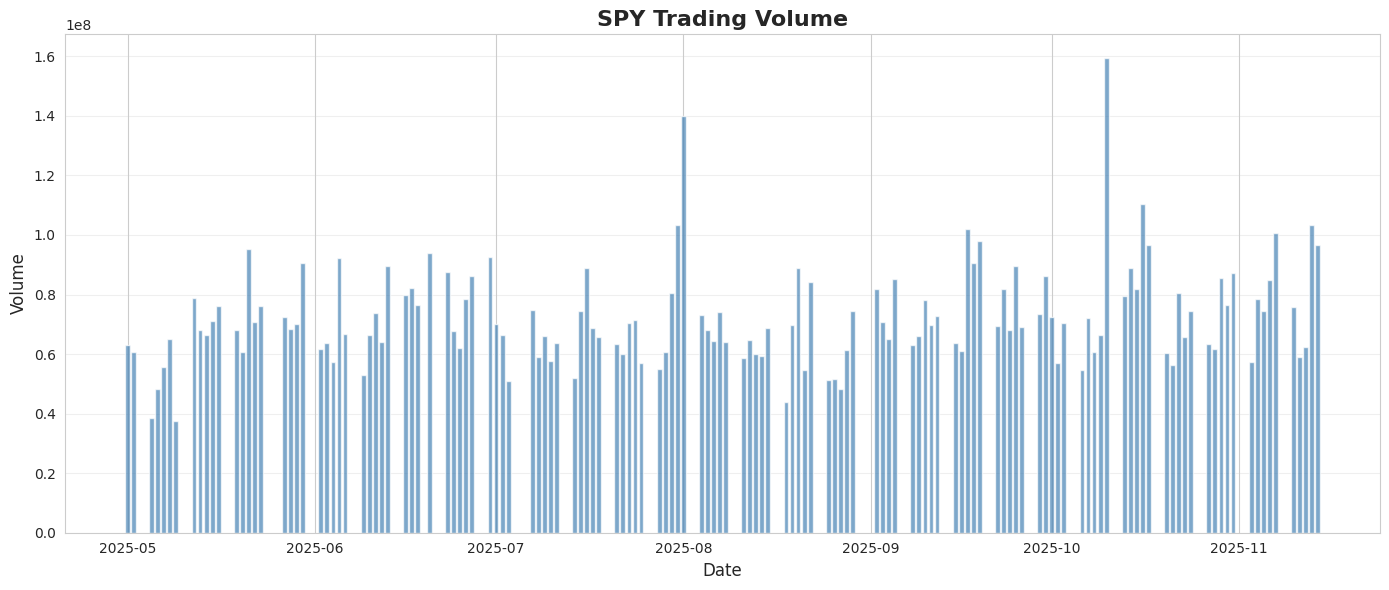

In [5]:
# Cell 5: Volume Analysis
plt.figure(figsize=(14, 6))
plt.bar(spy_df.index, spy_df['Volume'], alpha=0.7, color='steelblue')
plt.title('SPY Trading Volume', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Volume', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

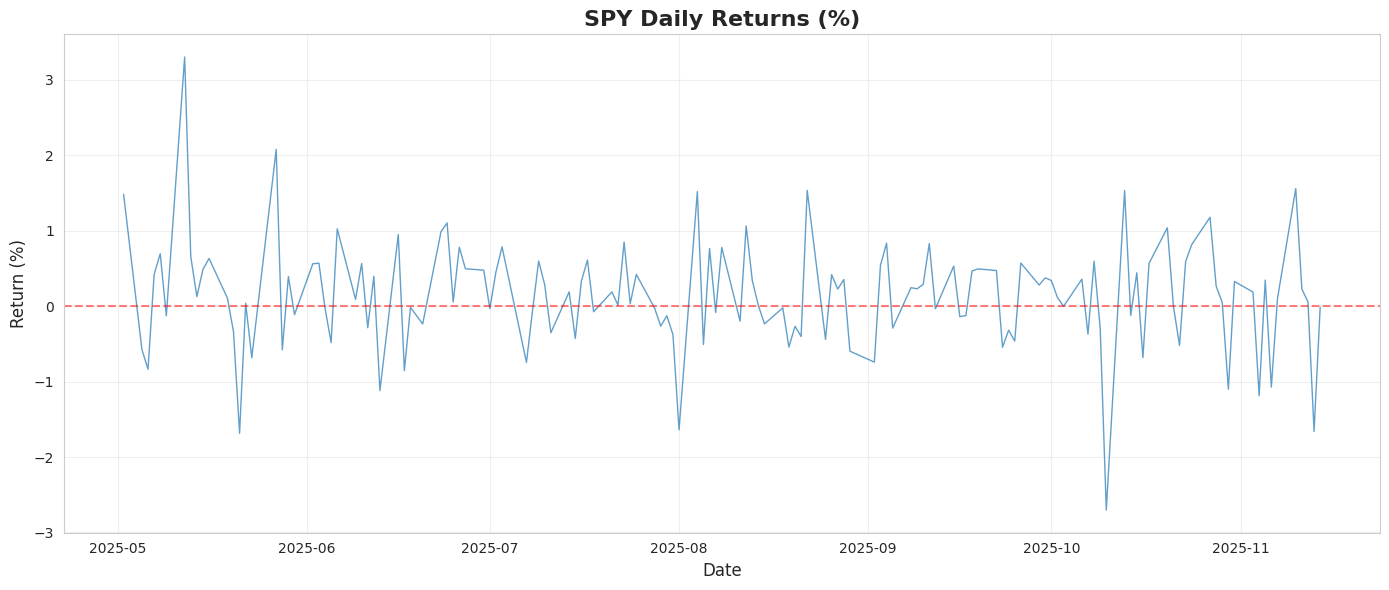

Mean daily return: 0.142%
Std daily return: 0.742%


In [6]:
# Cell 6: Calculate Daily Returns
spy_df['Daily_Return'] = spy_df['Close'].pct_change() * 100

plt.figure(figsize=(14, 6))
plt.plot(spy_df.index, spy_df['Daily_Return'], alpha=0.7, linewidth=1)
plt.title('SPY Daily Returns (%)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Return (%)', fontsize=12)
plt.axhline(y=0, color='r', linestyle='--', alpha=0.5)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Mean daily return: {spy_df['Daily_Return'].mean():.3f}%")
print(f"Std daily return: {spy_df['Daily_Return'].std():.3f}%")

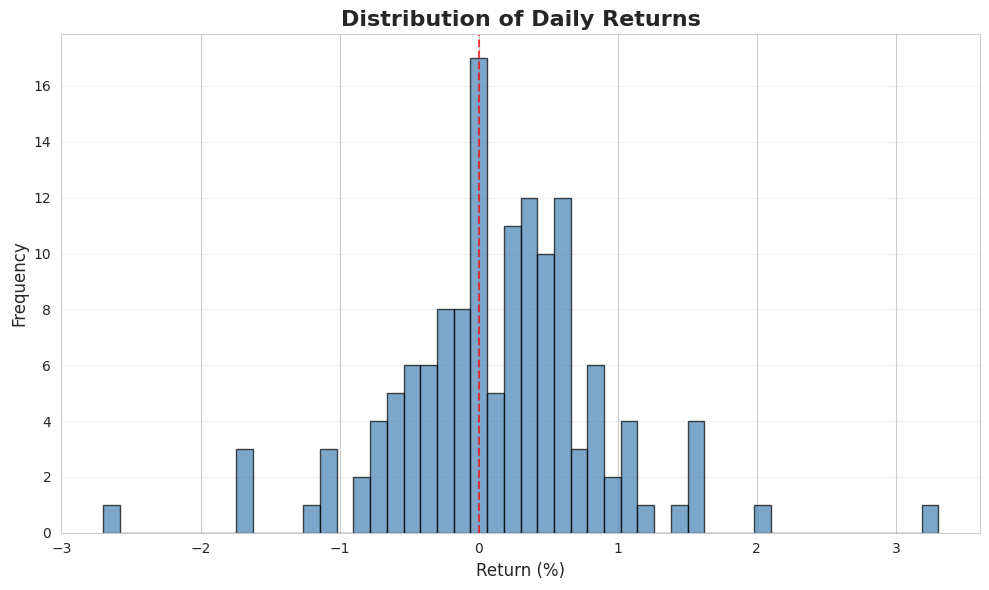

In [7]:
# Cell 7: Distribution of Returns
plt.figure(figsize=(10, 6))
spy_df['Daily_Return'].hist(bins=50, alpha=0.7, color='steelblue', edgecolor='black')
plt.title('Distribution of Daily Returns', fontsize=16, fontweight='bold')
plt.xlabel('Return (%)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.axvline(x=0, color='r', linestyle='--', alpha=0.7)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [8]:
# Cell 8: Load Multiple Tickers
tickers = ['SPY', 'QQQ', 'DIA']
dfs = {}

for ticker in tickers:
    df = pd.read_csv(data_dir / f'{ticker}_historical.csv', index_col=0, parse_dates=True)
    dfs[ticker] = df['Close']

combined_df = pd.DataFrame(dfs)
print(combined_df.head())

                                  SPY         QQQ         DIA
Date                                                         
2025-05-01 00:00:00-04:00  555.284363  480.582520  404.258667
2025-05-02 00:00:00-04:00  563.527100  487.716217  409.835083
2025-05-05 00:00:00-04:00  560.295654  484.822815  409.061096
2025-05-06 00:00:00-04:00  555.612488  480.313110  405.072296
2025-05-07 00:00:00-04:00  557.949097  482.198822  407.860474


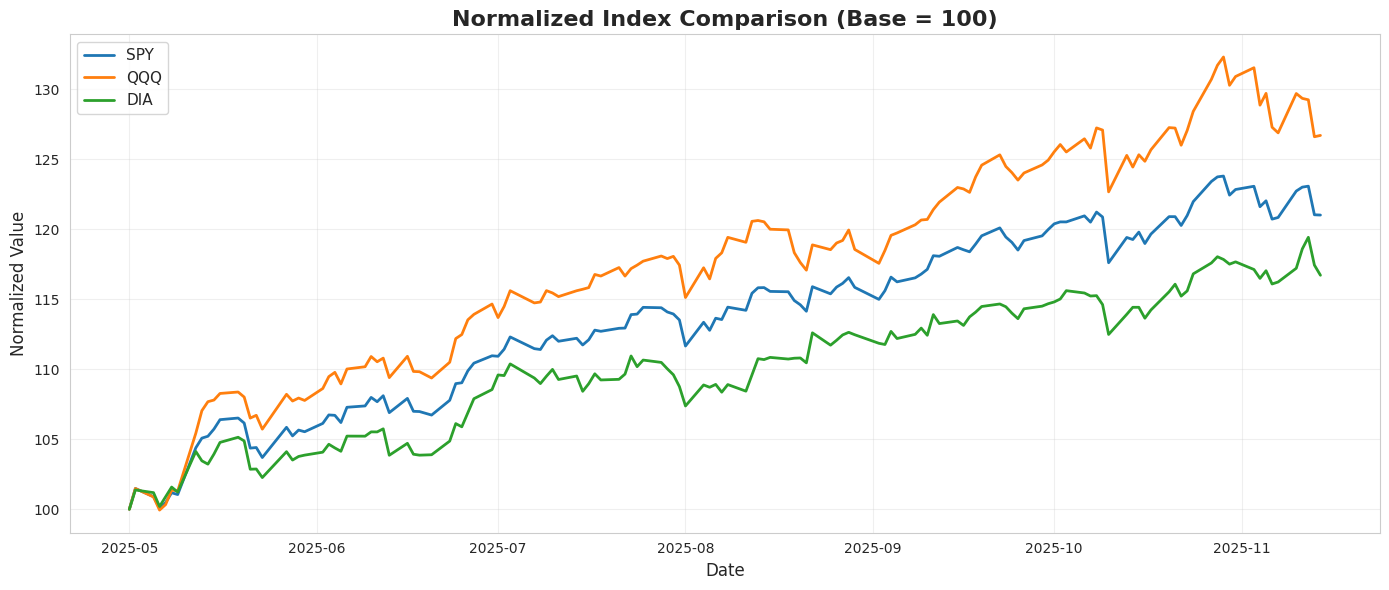

In [9]:
# Cell 9: Compare Multiple Indices
# Normalize to 100 for comparison
normalized = (combined_df / combined_df.iloc[0]) * 100

plt.figure(figsize=(14, 6))
for ticker in tickers:
    plt.plot(normalized.index, normalized[ticker], label=ticker, linewidth=2)

plt.title('Normalized Index Comparison (Base = 100)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Normalized Value', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

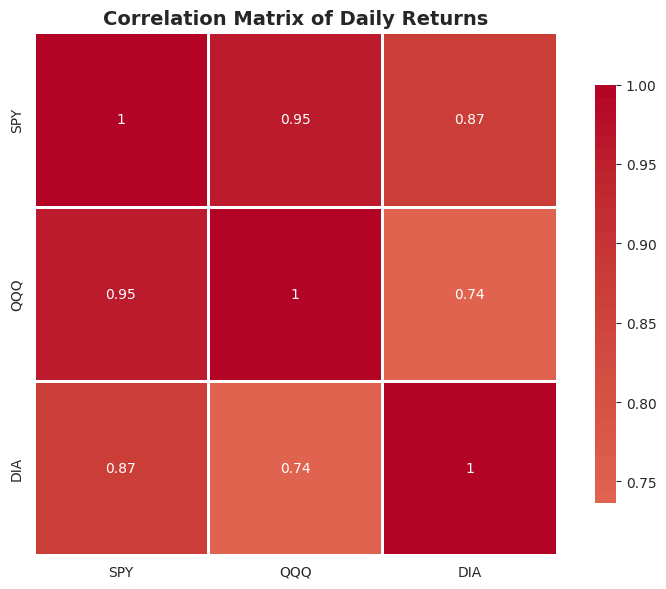

In [10]:
# Cell 10: Correlation Analysis
returns_df = combined_df.pct_change().dropna()

plt.figure(figsize=(8, 6))
sns.heatmap(returns_df.corr(), annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Daily Returns', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [11]:
# Cell 11: Save Analysis Summary
summary = {
    'Total Days': len(spy_df),
    'Date Range': f"{spy_df.index[0].date()} to {spy_df.index[-1].date()}",
    'Mean Daily Return': f"{spy_df['Daily_Return'].mean():.3f}%",
    'Volatility (Std)': f"{spy_df['Daily_Return'].std():.3f}%",
    'Max Daily Gain': f"{spy_df['Daily_Return'].max():.3f}%",
    'Max Daily Loss': f"{spy_df['Daily_Return'].min():.3f}%",
    'Current Price': f"${spy_df['Close'].iloc[-1]:.2f}"
}

print("\n" + "="*50)
print("DATA SUMMARY")
print("="*50)
for key, value in summary.items():
    print(f"{key:.<30} {value}")
print("="*50)


DATA SUMMARY
Total Days.................... 138
Date Range.................... 2025-05-01 to 2025-11-14
Mean Daily Return............. 0.142%
Volatility (Std).............. 0.742%
Max Daily Gain................ 3.305%
Max Daily Loss................ -2.703%
Current Price................. $671.93


In [12]:
# Cell 12: Save processed data
print("\n✓ EDA Complete!")
print("Next steps:")
print("1. Create technical indicators")
print("2. Process news sentiment")
print("3. Build LSTM model")


✓ EDA Complete!
Next steps:
1. Create technical indicators
2. Process news sentiment
3. Build LSTM model
